# Predicting Donor Retention for NayePankh Foundation
### A Machine Learning Internship Project

**Author:** Akash Gutti &nbsp;

---

## 1. Introduction & Objective

NayePankh Foundation is a student-led NGO that relies on the generosity of donors to fund its food, education, clothing and sanitary-pad drives. For any non-profit, **keeping an existing donor is far cheaper and easier than finding a new one** — yet most first-time donors never give a second time.

> **Objective:** Build a machine learning model that predicts whether a **first-time donor will donate again within 12 months**, and identify **which factors most influence repeat giving**, so NayePankh can focus its limited outreach on the donors most worth nurturing and understand what drives loyalty.

**What this notebook does, end to end:**
1. Generates a realistic (synthetic) donor dataset
2. Explores the data visually
3. Cleans and engineers features
4. Trains and **compares four models** (from a simple baseline up to XGBoost)
5. Evaluates them with the right metrics for this problem
6. Explains the best model with **feature importance and SHAP**
7. Turns the results into **plain-language recommendations** for the Foundation

> ⚠️ **Note on data:** The dataset here is **fully synthetic**, generated for this project. It contains no real donor information. The pipeline, however, is exactly what would be applied to NayePankh's real data once collected.

In [ ]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)
from xgboost import XGBClassifier
import shap

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
print("Libraries loaded.")

## 2. Loading the Data

We load the donor dataset. Each row is **one first-time donor**, with details about their first donation, plus whether they ended up donating again (`donated_again`: 1 = yes, 0 = no). That last column is our **prediction target**.

In [ ]:
df = pd.read_csv("donations.csv")
print(f"Dataset shape: {df.shape[0]} donors, {df.shape[1]} columns")
df.head()

Dataset shape: 3000 donors, 11 columns


,donor_id,first_gift_amount,donation_channel,campaign_source,city,donor_age_band,first_gift_month,is_festival_season,communication_optin,time_on_first_visit_secs,donated_again
0,D1000,745,BankTransfer,SocialMedia,Ghaziabad,18-25,11,1,1,104,0
1,D1001,291,Cash,SocialMedia,Delhi,26-35,11,1,1,303,0
2,D1002,1018,Cash,SocialMedia,Delhi,18-25,12,0,0,205,1
3,D1003,1163,BankTransfer,Website,Delhi,26-35,3,0,1,94,1
4,D1004,154,BankTransfer,Event,Kanpur,51+,11,1,0,10,1


In [ ]:
# Quick look at columns and types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   donor_id                  3000 non-null   str  
 1   first_gift_amount         3000 non-null   int64
 2   donation_channel          3000 non-null   str  
 3   campaign_source           3000 non-null   str  
 4   city                      3000 non-null   str  
 5   donor_age_band            3000 non-null   str  
 6   first_gift_month          3000 non-null   int64
 7   is_festival_season        3000 non-null   int64
 8   communication_optin       3000 non-null   int64
 9   time_on_first_visit_secs  3000 non-null   int64
 10  donated_again             3000 non-null   int64
dtypes: int64(6), str(5)
memory usage: 257.9 KB


**Feature glossary**

| Column | Meaning |
|---|---|
| `first_gift_amount` | Size of the donor's first donation (INR) |
| `donation_channel` | How they paid (UPI / Card / Cash / BankTransfer) |
| `campaign_source` | What brought them in (SocialMedia / Event / Website / Referral) |
| `city` | Donor location |
| `donor_age_band` | Age group |
| `first_gift_month` | Month of first gift (1–12) |
| `is_festival_season` | 1 if first gift was during festival season (Sep–Nov) |
| `communication_optin` | 1 if they agreed to receive updates |
| `time_on_first_visit_secs` | Seconds spent on the site during first visit |
| **`donated_again`** | **TARGET** — 1 if they donated again within 12 months |

## 3. Exploratory Data Analysis (EDA)

Before modelling, we look at the data to understand it and spot patterns. This is also where the Foundation can already learn useful things.

Repeat-donor rate: 61.8%
donated_again
1    1853
0    1147
Name: count, dtype: int64


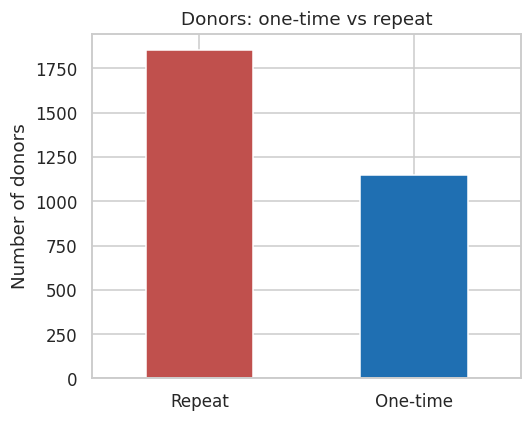

In [ ]:
# How balanced is the target?
repeat_rate = df["donated_again"].mean()
print(f"Repeat-donor rate: {repeat_rate:.1%}")
print(df["donated_again"].value_counts())

fig, ax = plt.subplots(figsize=(5,4))
df["donated_again"].map({0:"One-time", 1:"Repeat"}).value_counts().plot(
    kind="bar", color=["#c0504d", "#1f6fb2"], ax=ax)
ax.set_title("Donors: one-time vs repeat")
ax.set_ylabel("Number of donors"); ax.set_xlabel("")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

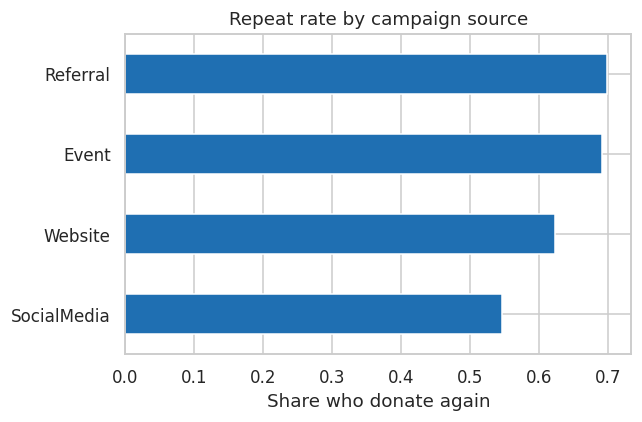

In [ ]:
# Repeat rate by campaign source — which channels bring loyal donors?
fig, ax = plt.subplots(figsize=(6,4))
(df.groupby("campaign_source")["donated_again"].mean().sort_values()
   .plot(kind="barh", color="#1f6fb2", ax=ax))
ax.set_title("Repeat rate by campaign source")
ax.set_xlabel("Share who donate again"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

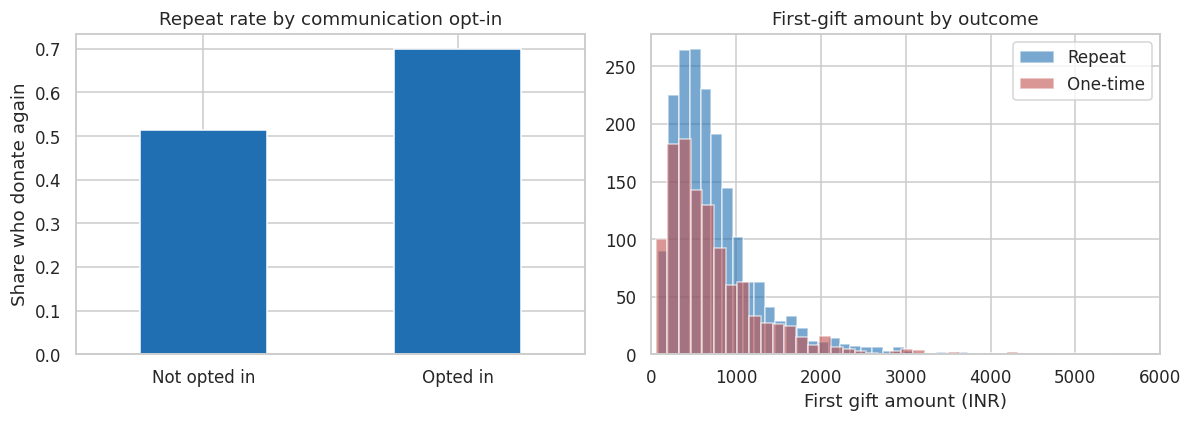

In [ ]:
# Repeat rate by opt-in and first-gift amount
fig, axes = plt.subplots(1, 2, figsize=(11,4))

(df.groupby("communication_optin")["donated_again"].mean()
   .rename({0:"Not opted in",1:"Opted in"})
   .plot(kind="bar", color="#1f6fb2", ax=axes[0]))
axes[0].set_title("Repeat rate by communication opt-in")
axes[0].set_ylabel("Share who donate again"); axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=0)

# first gift amount distribution split by outcome
for val, lab, col in [(1,"Repeat","#1f6fb2"),(0,"One-time","#c0504d")]:
    axes[1].hist(df.loc[df.donated_again==val,"first_gift_amount"],
                 bins=40, alpha=0.6, label=lab, color=col)
axes[1].set_xlim(0, 6000)
axes[1].set_title("First-gift amount by outcome")
axes[1].set_xlabel("First gift amount (INR)"); axes[1].legend()
plt.tight_layout(); plt.show()

**Early observations (already useful to NayePankh):**
- Donors who **opt in to communication** repeat far more often — permission to stay in touch matters.
- **Referrals and events** tend to produce more loyal donors than social-media one-offs.
- **Very small and very large** first gifts repeat less than mid-sized ones — there appears to be a "sweet spot".

The model will now confirm and rank these effects properly.

## 4. Preprocessing & Feature Engineering

Models need clean, numeric inputs. We:
- separate the **target** from the **features**,
- drop the ID column (not predictive),
- one-hot encode the categorical columns (turn text categories into 0/1 columns),
- leave numeric columns as they are.

We use a scikit-learn `ColumnTransformer` so the exact same preparation is applied identically to training and test data — avoiding mistakes.

In [ ]:
# Separate target and features
y = df["donated_again"]
X = df.drop(columns=["donated_again", "donor_id"])

categorical = ["donation_channel", "campaign_source", "city", "donor_age_band"]
numeric = ["first_gift_amount", "first_gift_month", "is_festival_season",
           "communication_optin", "time_on_first_visit_secs"]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("num", "passthrough", numeric),
])
print("Categorical features:", categorical)
print("Numeric features:    ", numeric)

Categorical features: ['donation_channel', 'campaign_source', 'city', 'donor_age_band']
Numeric features:     ['first_gift_amount', 'first_gift_month', 'is_festival_season', 'communication_optin', 'time_on_first_visit_secs']


## 5. Train / Test Split

We split the data **80% for training, 20% for testing**. The model learns only from the training set; the test set is kept hidden and used to grade how well the model works on donors it has never seen. We use `stratify` so the repeat/one-time ratio is the same in both halves.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print(f"Training donors: {len(X_train)}")
print(f"Testing donors:  {len(X_test)}")

Training donors: 2400
Testing donors:  600


## 6. Model Training & Comparison

We compare **four models of increasing sophistication**. This is deliberate: starting simple proves that the more complex models are actually *earning* their complexity, rather than assuming the fanciest model is best.

1. **Dummy (baseline)** — always predicts the most common outcome. The bar everything else must beat.
2. **Logistic Regression** — a simple, transparent linear model.
3. **Random Forest** — many decision trees combined.
4. **XGBoost** — gradient-boosted trees; usually the strongest on this kind of tabular data.

In [ ]:
models = {
    "Dummy (baseline)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8,
                                            random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                             subsample=0.9, colsample_bytree=0.9,
                             eval_metric="logloss", random_state=RANDOM_STATE),
}

results = []
fitted = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    pred = pipe.predict(X_test)
    # predicted probability (Dummy has no meaningful proba for AUC)
    try:
        proba = pipe.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)
    except Exception:
        auc = np.nan
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": auc,
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Dummy (baseline),0.618,0.618,1.000,0.764,0.500
Logistic Regression,0.643,0.665,0.854,0.748,0.640
Random Forest,0.650,0.661,0.892,0.759,0.641
XGBoost,0.612,0.659,0.771,0.711,0.612


### Reading the comparison

For a retention problem, **accuracy alone is misleading** — because most donors repeat, a lazy model that predicts "everyone repeats" already looks decent. What we really care about is:
- **Recall** — of the donors who *will* repeat, how many did we correctly catch?
- **F1** — the balance between precision and recall.
- **ROC-AUC** — how well the model separates repeaters from non-repeaters overall (0.5 = guessing, 1.0 = perfect).

The chart below compares the models on these.

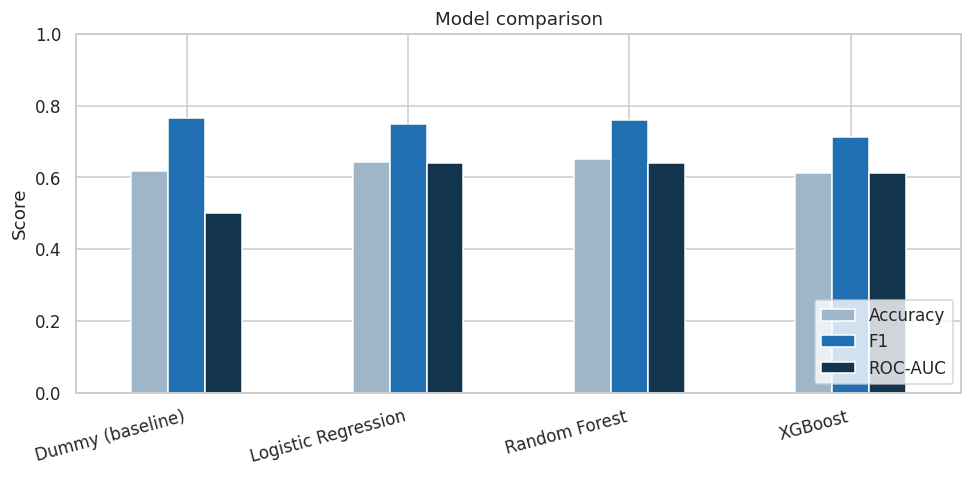

In [ ]:
fig, ax = plt.subplots(figsize=(9,4.5))
results_df[["Accuracy","F1","ROC-AUC"]].plot(kind="bar", ax=ax,
    color=["#9fb6c9","#1f6fb2","#12344d"])
ax.set_title("Model comparison")
ax.set_ylabel("Score"); ax.set_ylim(0,1); ax.set_xlabel("")
plt.xticks(rotation=15, ha="right"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

In [ ]:
# Pick the best model by F1 (ignoring the dummy baseline)
ranked = results_df.drop(index="Dummy (baseline)").sort_values("F1", ascending=False)
best_name = ranked.index[0]
best_model = fitted[best_name]
print(f"Best model by F1: {best_name}")
ranked

Best model by F1: Random Forest


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest,0.650,0.661,0.892,0.759,0.641
Logistic Regression,0.643,0.665,0.854,0.748,0.640
XGBoost,0.612,0.659,0.771,0.711,0.612


## 7. Evaluation of the Best Model

We look more closely at the winning model with a **confusion matrix** (what it got right and wrong) and an **ROC curve**.

In [ ]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(f"Classification report — {best_name}\n")
print(classification_report(y_test, y_pred, target_names=["One-time","Repeat"]))

Classification report — Random Forest

              precision    recall  f1-score   support

    One-time       0.60      0.26      0.36       229
      Repeat       0.66      0.89      0.76       371

    accuracy                           0.65       600
   macro avg       0.63      0.57      0.56       600
weighted avg       0.64      0.65      0.61       600



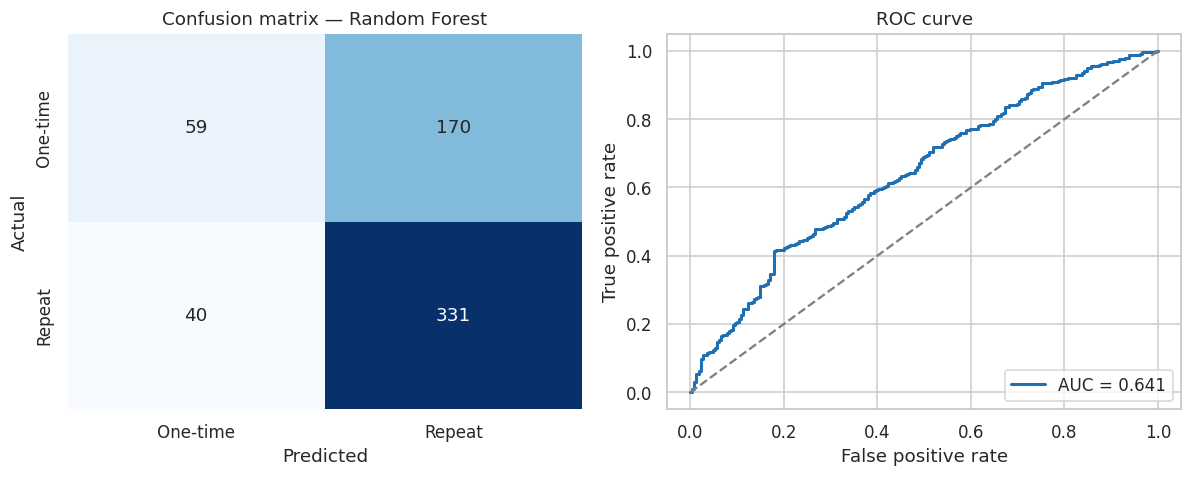

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["One-time","Repeat"],
            yticklabels=["One-time","Repeat"], ax=axes[0])
axes[0].set_title(f"Confusion matrix — {best_name}")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#1f6fb2", lw=2, label=f"AUC = {auc:.3f}")
axes[1].plot([0,1],[0,1], "--", color="grey")
axes[1].set_title("ROC curve")
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

## 8. What Drives Repeat Giving? — Feature Importance & SHAP

A prediction is only useful to NayePankh if we can explain **why**. We use two views:
- **Feature importance** — which factors the model relied on most.
- **SHAP** — not just *how strong* each factor is, but *which direction* it pushes the outcome (towards repeating or not).

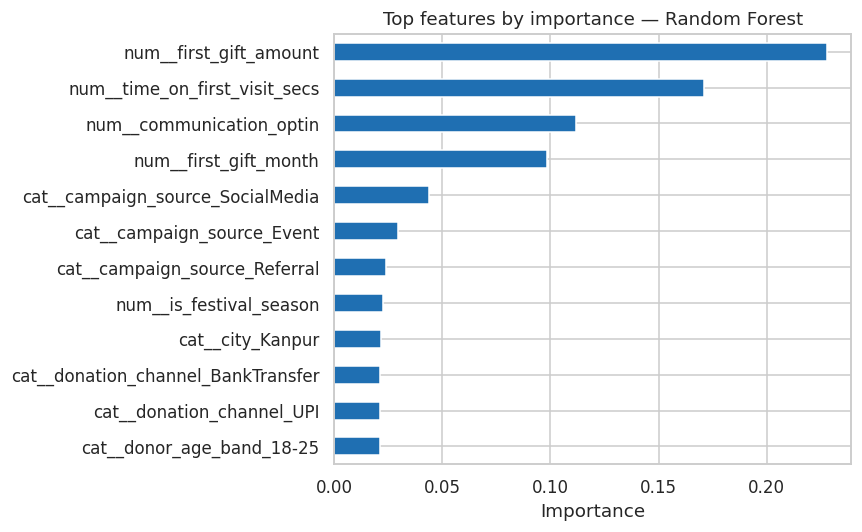

In [ ]:
# Built-in importance from the best tree model
prep = best_model.named_steps["prep"]
model_only = best_model.named_steps["model"]
feature_names = prep.get_feature_names_out()

if hasattr(model_only, "feature_importances_"):
    imp = (pd.Series(model_only.feature_importances_, index=feature_names)
             .sort_values(ascending=False).head(12))
    fig, ax = plt.subplots(figsize=(8,5))
    imp.iloc[::-1].plot(kind="barh", color="#1f6fb2", ax=ax)
    ax.set_title(f"Top features by importance — {best_name}")
    ax.set_xlabel("Importance"); plt.tight_layout(); plt.show()
else:
    print("Selected model has no native feature_importances_.")

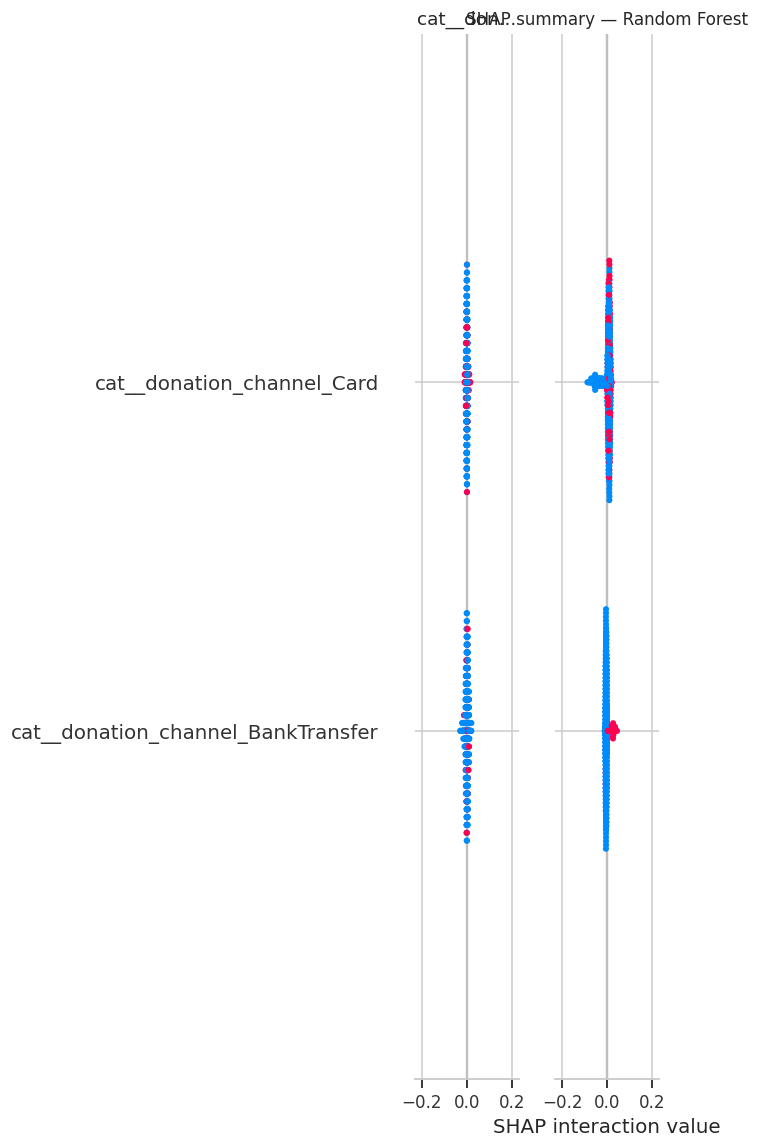

In [ ]:
# SHAP — directional explanation (works cleanly for the tree models)
X_test_prep = prep.transform(X_test)
if hasattr(X_test_prep, "toarray"):
    X_test_prep = X_test_prep.toarray()
X_test_prep_df = pd.DataFrame(X_test_prep, columns=feature_names)

explainer = shap.TreeExplainer(model_only)
shap_values = explainer.shap_values(X_test_prep_df)

shap.summary_plot(shap_values, X_test_prep_df, show=False, max_display=12)
plt.title(f"SHAP summary — {best_name}", fontsize=11)
plt.tight_layout(); plt.show()

**How to read the SHAP plot:** each dot is a donor. Dots to the **right** push the prediction **towards repeating**; dots to the **left** push **away**. Colour shows whether that feature's value was high (red) or low (blue). For example, a high `communication_optin` (red) sitting on the right means opting in pushes donors towards repeating — exactly what the Foundation would hope.

## 9. Insights & Recommendations for NayePankh Foundation

Bringing the modelling back to action. Based on the patterns the model found:

1. **Always ask donors to opt in to updates.** Opt-in is consistently among the strongest signals of repeat giving. A single checkbox at donation time is one of the cheapest retention levers available.
2. **Invest in referral and event channels.** These bring more loyal donors than one-off social-media gifts. Encourage existing donors to refer friends.
3. **Nurture mid-sized first-time donors.** They are the most likely to give again — a warm thank-you and a second, specific ask can convert them.
4. **Use festival season deliberately.** First gifts made during festival months are linked to higher repeat rates; plan follow-up campaigns around them.
5. **Score new donors automatically.** The model can flag each new first-time donor as higher- or lower-likelihood to repeat, so the team spends its limited outreach time where it will pay off most.

## 10. Limitations & Next Steps

Being honest about what this project can and cannot claim:

- **Synthetic data.** The dataset is generated, not real. The *pipeline* is valid and ready, but the specific numbers would change on NayePankh's actual data.
- **Importance is not causation.** The model shows which factors are *associated* with repeat giving — it does not prove that changing one (e.g. forcing opt-in) would directly cause more repeats.
- **Limited features.** Real donor behaviour depends on things not captured here (personal circumstances, the cause's appeal at the time, economic conditions).
- **One snapshot in time.** With more history, time-based patterns and seasonality could be modelled far more reliably.

**Next steps:** collect real donation data in the structured form described above, re-run this exact notebook on it, and connect the model's score to a simple dashboard the team checks monthly.

---
*Built as a selection task for the NayePankh Foundation Machine Learning Internship. Dataset is fully synthetic; no real donor data was used.*